In [37]:
from pathlib import Path
import sys

def _find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "pyresdmd").exists():
            return path
    raise RuntimeError("Could not find repo root containing pyproject.toml and pyresdmd/")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Found pyresdmd root.")

Found pyresdmd root.


In [38]:
import numpy as np
import time
import torch
import matplotlib.pyplot as plt

from pyresdmd.compute.spectra import (
    compute_eigendecomposition_from_weights,
    compute_pseudospectra,
)
from pyresdmd.dicts.chebyshev_dictionary import ChebyshevDictionary
from pyresdmd.dicts.hermite_dictionary import HermiteDictionary
from pyresdmd.dicts import TensorProductDictionary
from pyresdmd.dicts.nn.relu.relu_dictionary import ReLUDictionary
from pyresdmd.dicts.trainable_dictionary import TrainableDictionary
from pyresdmd.utils.helpers import benchmark_metrics
from pyresdmd.utils.plotters import plot_curve, plot_pseudospec
from pyresdmd.sims.duffing import duffing, duffing_cts

print("Imports successful.")

Imports successful.


In [39]:
if torch.cuda.is_available():
    print("CUDA is available. Using GPU for computations.")
    device = torch.device("cuda")
else:
    print("No CUDA-supported device found. Using CPU for computations.")
    device = torch.device("cpu")

CUDA is available. Using GPU for computations.


In [ ]:
# Simulation and demo parameters
dt : float = 0.05 # 0.05
delta : float = 0.3
alpha : float = -1.0
beta : float = 1.0
noise : float = 0.0
n_trajectories : int = 1500
hidden_dim : int = 32
steps : int = 40
epochs : int = 500
patience : int = 50
dictionary_size : int = 100

print("Parameters set.")

Parameters set.


In [ ]:
def rand_point() -> torch.Tensor:
        '''Generates a random point in the state space. Samples uniformly from the box [-3, 3]^2'''
        return 6*torch.rand(2, device = device) - 3 # sample uniformly from [-3, 3]^2

initial_states = [rand_point() for _ in range(n_trajectories)]

x, y = duffing_cts(initial_states, dt = dt, delta = delta, alpha = alpha, beta = beta, steps = steps, noise = noise, device = device)


print("Trajectory data generated.")

first discrete
now doing cts
Trajectory data generated.


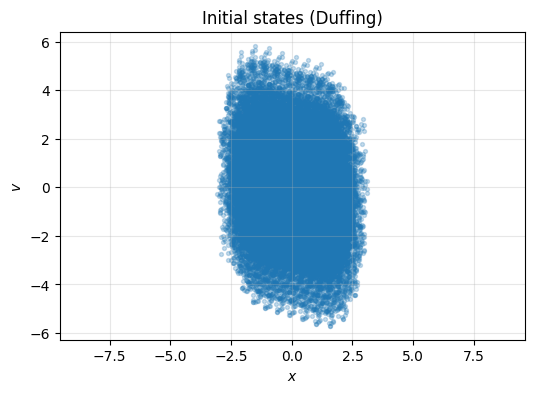

In [42]:
plt.figure(figsize=(6,4))
plt.scatter(x.cpu().detach().numpy()[:,0], x.cpu().detach().numpy()[:,1], alpha=0.25, s=8)
plt.xlabel('$x$')
plt.ylabel('$v$')
plt.title('Initial states (Duffing)')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

Initial eigenvalues: tensor([-0.0062+0.6360j, -0.0062-0.6360j, -0.1347+0.4520j, -0.1347-0.4520j,
        -0.2195+0.2650j, -0.2195-0.2650j, -0.0209+0.4188j, -0.0209-0.4188j,
         0.0923+0.5487j,  0.0923-0.5487j,  0.3169+0.6879j,  0.3169-0.6879j,
         0.2307+0.6314j,  0.2307-0.6314j,  0.4478+0.7021j,  0.4478-0.7021j,
         0.0016+0.2346j,  0.0016-0.2346j, -0.0459+0.0458j, -0.0459-0.0458j,
         0.1766+0.4520j,  0.1766-0.4520j,  0.5688+0.6428j,  0.5688-0.6428j,
         0.0526+0.0147j,  0.0526-0.0147j,  0.6817+0.5993j,  0.6817-0.5993j,
         0.5454+0.5860j,  0.5454-0.5860j,  0.3933+0.4843j,  0.3933-0.4843j,
         0.2951+0.3627j,  0.2951-0.3627j,  0.6727+0.5367j,  0.6727-0.5367j,
         0.1798+0.0000j,  0.8075+0.4782j,  0.8075-0.4782j,  0.5605+0.4832j,
         0.5605-0.4832j,  0.2571+0.2437j,  0.2571-0.2437j,  0.2146+0.1084j,
         0.2146-0.1084j,  0.7112+0.4577j,  0.7112-0.4577j,  0.8389+0.3887j,
         0.8389-0.3887j,  0.3910+0.2445j,  0.3910-0.2445j,  0.5322+

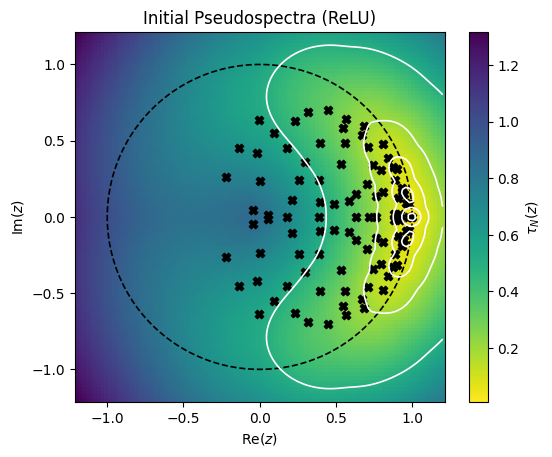

In [43]:
# create and evaluate untrained ReLU dictionary (trainable) for initial metrics
base = ReLUDictionary(input_dim = 2, n_functions = dictionary_size, hidden_dim = hidden_dim)
dictionary = TrainableDictionary(base)
dictionary.to(device)

with torch.no_grad():
    report = dictionary.report(x, y)
    Psi_X, Psi_Y = dictionary.evaluate(x), dictionary.evaluate(y)
init_eigvals = report['eigenvalues']
init_loss = report['loss']
init_cond_num = report['cond_num']
init_forecast_error = report['forecast_error']
init_pseudospec = compute_pseudospectra(Psi_X, Psi_Y)
del Psi_X, Psi_Y
eps_levels = [1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1]

print(f"Initial eigenvalues: {init_eigvals}")
print(f"Initial loss: {init_loss}")
print(f"Initial condition number: {init_cond_num}")
print(f"Initial forecast error: {init_forecast_error}")

re_vals = init_pseudospec['re_vals']
im_vals = init_pseudospec['im_vals']
tau_grid = init_pseudospec['tau_grid']
plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = init_eigvals, displayname = 'Initial Pseudospectra (ReLU)', save = False)

del re_vals, im_vals, tau_grid, init_pseudospec

In [44]:
print(1/torch.max(torch.abs(x)).item())

0.17137715383690702


Hermite eigvals: tensor([-0.4828+0.6481j, -0.4828-0.6481j, -0.6303+0.4590j, -0.6303-0.4590j,
        -0.6361+0.4297j, -0.6361-0.4297j, -0.7179+0.1617j, -0.7179-0.1617j,
        -0.3471+0.7518j, -0.3471-0.7518j, -0.6747+0.0248j, -0.6747-0.0248j,
        -0.1942+0.8705j, -0.1942-0.8705j, -0.6236+0.2548j, -0.6236-0.2548j,
        -0.4833+0.5553j, -0.4833-0.5553j, -0.3482+0.6677j, -0.3482-0.6677j,
        -0.5740+0.2465j, -0.5740-0.2465j,  0.0092+0.8963j,  0.0092-0.8963j,
        -0.1831+0.7528j, -0.1831-0.7528j, -0.5403+0.1256j, -0.5403-0.1256j,
        -0.3957+0.4107j, -0.3957-0.4107j,  0.1942+0.8783j,  0.1942-0.8783j,
        -0.0666+0.6882j, -0.0666-0.6882j, -0.3819+0.1118j, -0.3819-0.1118j,
        -0.2280+0.4709j, -0.2280-0.4709j,  0.0581+0.7852j,  0.0581-0.7852j,
         0.0144+0.7425j,  0.0144-0.7425j,  0.2364+0.8228j,  0.2364-0.8228j,
         0.1334+0.7842j,  0.1334-0.7842j, -0.2794+0.1650j, -0.2794-0.1650j,
         0.3689+0.8296j,  0.3689-0.8296j,  0.3827+0.8188j,  0.3827-0.81

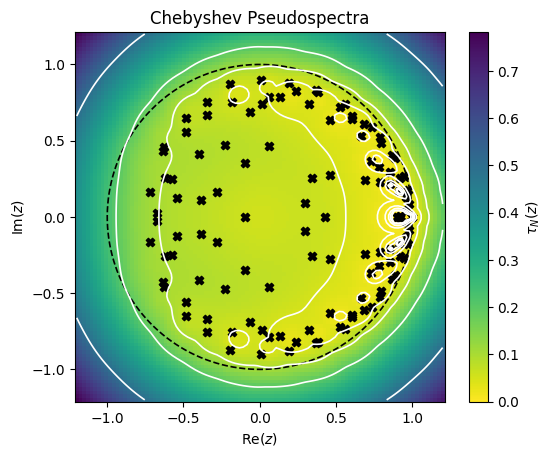

In [45]:
# Chebyshev tensor-product benchmark

size = int(dictionary_size**0.5)
cheb_dict = TensorProductDictionary(ChebyshevDictionary(size, scale = 1/torch.max(torch.abs(x[:, 0]))), ChebyshevDictionary(size, scale = 1/torch.max(torch.abs(x[:, 1]))))
cheb_dict.to(device)
cheb_metrics = benchmark_metrics(cheb_dict, x, y)
cheb_pseudospec = cheb_metrics['pseudospec']
Lambda = cheb_metrics['Lambda']
cheb_cond_num = cheb_metrics['cond_num']
cheb_loss = cheb_metrics['loss']
cheb_forecast_error = cheb_metrics['forecast_error']

print(f"Hermite eigvals: {Lambda}")
print(f"Hermite loss: {cheb_loss}")
print(f"Hermite condition number: {cheb_cond_num}")
print(f"Hermite forecast error: {cheb_forecast_error}")

re_vals = cheb_pseudospec['re_vals']
im_vals = cheb_pseudospec['im_vals']
tau_grid = cheb_pseudospec['tau_grid']
plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = Lambda, displayname = 'Chebyshev Pseudospectra', save = False)

Dictionary trained.
Best loss: 0.022224992513656616
Condition number of best model: 668.783203125
Forecast error of best model: 0.0003708014846779406


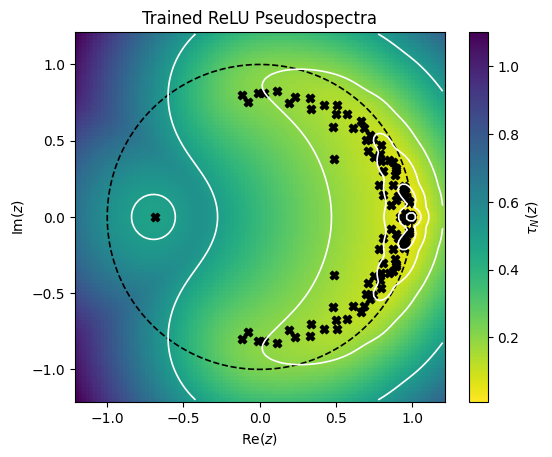

In [ ]:
# allow several minutes depending on parameters and dictionary size
trained = dictionary.fit(x, y, epochs = epochs, patience = patience, batch_size = 0.05)
print("Dictionary trained.")
train_losses = trained['train_losses']
test_losses = trained['test_losses']
train_cond_nums = trained['train_cond_nums']
test_cond_nums = trained['test_cond_nums']
train_forecast_errors = trained['train_forecast_errors']
test_forecast_errors = trained['test_forecast_errors']
final_epoch = trained['final_epoch']

# with torch.no_grad():
#    best_report = dictionary.report(x, y)
#    Psi_X, Psi_Y = dictionary.evaluate(x), dictionary.evaluate(y)
best_loss = np.argmin(test_losses)
best_cond_num = test_cond_nums[best_loss]
best_forecast_error = test_forecast_errors[best_loss]

final_pseudospec = compute_pseudospectra(Psi_X, Psi_Y)
W = torch.ones(x.shape[0], device = x.device) / x.shape[0]
final_eigvals, _ = compute_eigendecomposition_from_weights(Psi_X, Psi_Y, W)
del Psi_X, Psi_Y

print(f"Best loss: {best_loss}")
print(f"Condition number of best model: {best_cond_num}")
print(f"Forecast error of best model: {best_forecast_error}")
re_vals = final_pseudospec['re_vals']
im_vals = final_pseudospec['im_vals']
tau_grid = final_pseudospec['tau_grid']
plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = final_eigvals, displayname = 'Trained ReLU Pseudospectra', save = False)

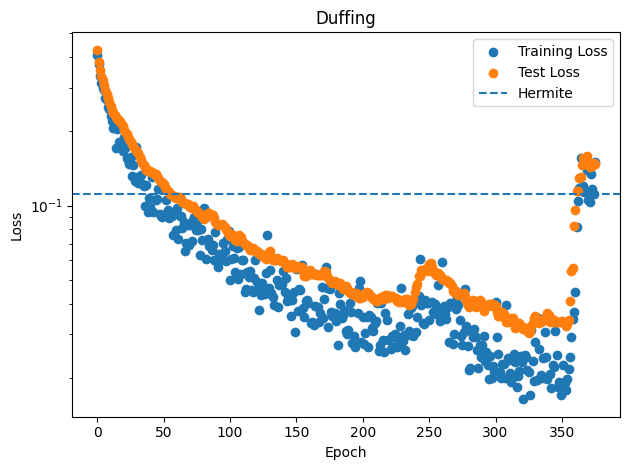

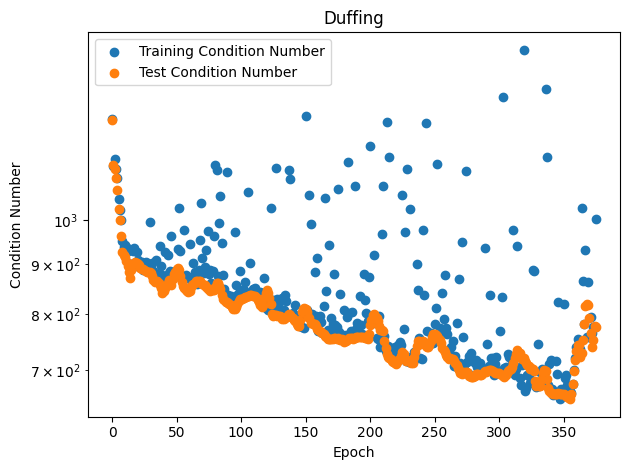

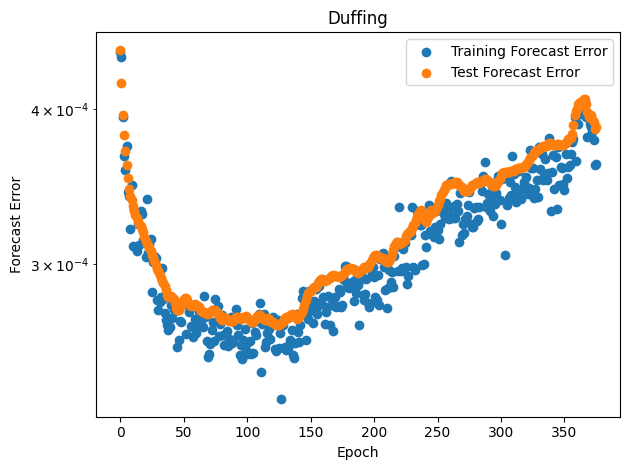

In [47]:
show_cheb_cond_num = False 
show_cheb_loss = True 
show_cheb_forecast_error = False

plot_curve(final_epoch, train_losses, test_losses, add_values = {'Hermite': cheb_loss} if show_cheb_loss else {}, 
                   displayname = 'Duffing', ylabel = 'Loss', save_plot = False)

plot_curve(final_epoch, train_cond_nums, test_cond_nums, add_values = {'Hermite': cheb_cond_num} if show_cheb_cond_num else {},
                        displayname = 'Duffing', ylabel = 'Condition Number', save_plot = False)

plot_curve(final_epoch, train_forecast_errors, test_forecast_errors, add_values = {'Hermite': cheb_forecast_error} if show_cheb_forecast_error else {},
                        displayname = 'Duffing', ylabel = 'Forecast Error', save_plot = False)

In [48]:
# cleanup VRAM
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()